![HOOPS AI](../images/HOOPS_AI.jpg)

# HOOPS AI: Transfer a Face Selection

Select a connected region on the source part and highlight a candidate region on the target. Source and target regions may contain different numbers of faces.

`RegionTransfer` handles region matching between two loaded parts. Results are approximate geometric candidates, not verified manufacturing correspondences.

In [1]:
import hoops_ai
import os
import sys

license_key = os.environ.get("HOOPS_AI_LICENSE")
if not license_key:
    sys.exit("HOOPS_AI_LICENSE environment variable is required.")

hoops_ai.set_license(license_key, validate=True)

------------------------------------------------------------
HOOPS AI
------------------------------------------------------------
  Platform      : Windows 11
  Architecture  : AMD64
  Python        : 3.12.10
------------------------------------------------------------
  Core          : hoops-ai             1.2.0
  CAD Access    : hoops-exchange       26.8.0.dev1  (build: 87762679 2026-09-09T10:20:34Z)
  Conversion    : hoops-converter      26.1.2.dev10  (build: 71b6907 2026-07-24T12:00:12Z)
  Insights      : hoops-web-viewer     0.1.6
------------------------------------------------------------
[OK] HOOPS AI License: Valid


# Index a dataset for part search

In [2]:
from hoops_ai.storage import CADFileRetriever, LocalStorageProvider

import pathlib

cad_sources = pathlib.Path.cwd().parent.joinpath("packages", "cadfiles", "workflow_transfer","diff_file_formats")
output_dir = pathlib.Path.cwd().joinpath("out", "workflow_transfer")

if not cad_sources.exists():
    sys.exit(f"CAD dataset path does not exist: {cad_sources}")

retriever = CADFileRetriever(storage_provider=LocalStorageProvider(directory_path=cad_sources), 
formats=[".stp", ".step", ".iges", ".igs", ".CATPart", ".SLDPRT", ".prt", ".prt.1", ".jt", ".SAT", ".sat",
".prt.14",".prt.16", ".prt.27", ".prt.32", ".prt.33", ".prt.36", ".prt.41", ".prt.43"])

# Get files using the library's retriever
cad_files = retriever.get_file_list()
print(len(cad_files), "files found." )

output_dir.joinpath("images").mkdir(parents=True, exist_ok=True)       # needed by my_specs


# Graph and storage modes are left to the library: memory mode, packed storage on Windows, directory on Linux.
my_specs = {
    "generate_images": False,
    "images_out_dir": str(output_dir.joinpath("images")),
}

from hoops_ai.ml.embeddings import HOOPSEmbeddings

# HOOPS AI release 1.1
HOOPSEmbeddings.register_model(
    model_name="HOOPS Embeddings SIGNAL preview",
    checkpoint_path=str(pathlib.Path.cwd().parent.joinpath("packages","trained_ml_models", "ts3d_2M_hoops_embeddings_SIGNAL-preview.ckpt"))
)

SIGNAL_embeddings_model = HOOPSEmbeddings(model="HOOPS Embeddings SIGNAL preview", device="cuda")

demoEmbeddings = SIGNAL_embeddings_model.embed_shape_batch(cad_files, num_workers=22, show_progress=True, specifications=my_specs)

from hoops_ai.ml import CADSearch

emb_searcher = CADSearch(shape_model=SIGNAL_embeddings_model)

emb_searcher.index_shape(demoEmbeddings)

output_dir.joinpath("vectorstores").mkdir(parents=True, exist_ok=True) # needed by save_shape_index
emb_searcher.save_shape_index(output_dir.joinpath("vectorstores","workflow_transfer.faiss"))

33 files found.


Encoding CAD packs:   0%|          | 0/33 [00:00<?, ?it/s]

Embedding bodies:   0%|          | 0/4 [00:00<?, ?it/s]

[-0.04811943 -0.01847812  0.1888475  ...  0.04220196 -0.29323334
 -0.03442155]


Exporting stream cache PNGs:   0%|          | 0/6 [00:00<?, ?it/s]

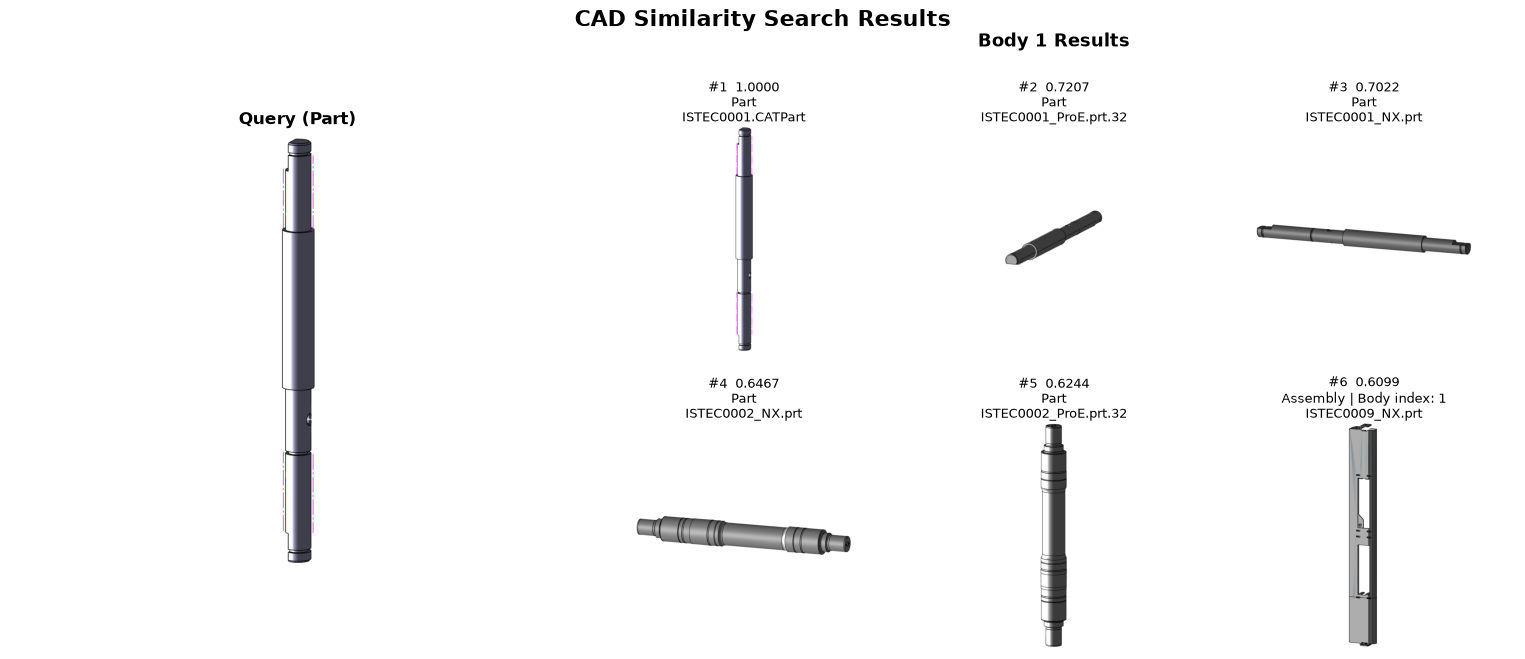

In [3]:

cad_folder = cad_sources.resolve()
#cad_filename_target = cad_folder / "NIST-FTC-CTC-PMI-CAD-models/CTC Definitions/nist_ctc_04_asme1_rd.stp"

#cad_filename = cad_folder / "NIST-FTC-CTC-PMI-CAD-models/Inventor 2021/INV_nist_ctc_04_asme1_2021.ipt"
#cad_filename = cad_folder / "CV5_Landing Gear Model/Wheel_Assy.CATProduct"
#cad_filename = cad_folder / "CV5_Landing Gear Model/Upright_Arm_Support.CATPart"
#cad_filename = cad_folder / "NIST-FTC-CTC-PMI-CAD-models/CTC Definitions/nist_ctc_02_asme1_rc.stp"
#cad_filename = cad_folder / "ISTEC0004.CATPart"
cad_filename = cad_folder / "ISTEC0001.CATPart"
query_file = str(cad_filename)
query_embeddings = SIGNAL_embeddings_model.embed_shape(query_file)[0]
print(query_embeddings.values)

hits = emb_searcher.search_by_embedding(query_embeddings, top_k=6 ) #

from hoops_ai.insights import DatasetViewer
ds_viewer = DatasetViewer([], [], [], reference_dir=pathlib.Path.cwd().joinpath("out","workflow_transfer","images"))
ds_viewer.show_search_results(hits, query_file=query_file, grid_cols=3)



In [4]:
cad_filename_target = hits[1].id
print(cad_filename_target)

#cad_folder = (pathlib.Path.cwd().parent / "packages" / "cadfiles" / "workflow_transfer").resolve()
#cad_filename = cad_folder / "nist_mtc_crada_plate_rev-A.SLDPRT"
#cad_filename_target = cad_folder / "nist_stc_09_asme1_ap242-e3.stp"

c:\Users\LuisSalazar.LY-LS-LEGION\Documents\repos\HOOPS-AI-tutorials\packages\cadfiles\workflow_transfer\diff_file_formats\ISTEC0001_ProE.prt.32


## 1. Load the Parts and Initialize Region Transfer

Run from the `embeddings_pipeline` directory with the HOOPS AI environment and `HOOPS_AI_LICENSE` set. Run once for this pair of files. `RegionPart.load_from_file` encodes one body of a CAD file; pass `body_index` to pick another body of a multi-body file. `RegionTransfer` prepares and aligns both parts once for all later transfers.

In [5]:
import pathlib

from hoops_ai.dataset.region_transfer import Region, RegionPart, RegionTransfer

source_part = RegionPart.load_from_file(cad_filename, body_index=0)
target_part = RegionPart.load_from_file(cad_filename_target, body_index=0)
region_transfer = RegionTransfer(source_part, target_part)

## 2. Inspect the Source PMI

List the Product Manufacturing Information (PMI) stored in the source file: dimensions, tolerances, datums and notes. Each line shows the PMI id, its name and kind. Dimensions also show their type, value and tolerance. The arrow lists the other PMI entries it references, such as the datums of a position tolerance.

The value is in the model length unit, or radians for angles. The display unit is how the CAD tool shows it. Only dimensions carry semantic data today, and the PMI is not yet linked to faces.

In [6]:
from hoops_ai.cadaccess import PMI, HOOPSLoader, PMIKind


def format_pmi(pmi: PMI, pmis: list[PMI]) -> str:
    """One line per PMI: kind, dimension value and tolerance, and the PMI entries it references."""
    data = pmi.data
    text = f"{pmi.pmi_id:4d}  {pmi.name:<32} {data.type.value:<10}"
    if data.type is PMIKind.DIMENSION:
        value = "?" if data.value is None else f"{data.value:.6g}"
        text += f" {data.dimension_type or '?':<18} {value}"
        display_format = data.main_value.format if data.main_value else None
        if display_format is not None and display_format.unit:
            text += f" (display {display_format.unit})"
        tolerance = data.main_value.tolerance if data.main_value else None
        if tolerance is not None and (tolerance.lower, tolerance.upper) != (0.0, 0.0):
            text += f"  tol [{tolerance.lower}, {tolerance.upper}]"
    if pmi.referenced_pmi_ids:
        text += "  -> " + ", ".join(pmis[pmi_id].name for pmi_id in pmi.referenced_pmi_ids)
    return text


source_pmis: list[PMI] = HOOPSLoader().create_from_file(str(cad_filename)).get_pmi_list()
dimension_count = sum(pmi.data.type is PMIKind.DIMENSION for pmi in source_pmis)
print(f"{cad_filename.name}: {len(source_pmis)} PMI entries, {dimension_count} dimensions")
for pmi in source_pmis:
    print(format_pmi(pmi, source_pmis))

ISTEC0001.CATPart: 28 PMI entries, 9 dimensions
   0  Simple Datum.1                   unknown   
   1  Simple Datum.2                   unknown   
   2  Simple Datum.4                   unknown   
   3  Text.3                           unknown   
   4  Text.4                           unknown   
   5  Geometrical Tolerance.3          unknown   
   6  Roughness.3                      unknown   
   7  Geometrical Tolerance.7          unknown   
   8  Text.10                          unknown   
   9  Text.11                          unknown   
  10  Text.12                          unknown   
  11  Roughness.4                      unknown   
  12  Simple Datum.8                   unknown   
  13  Geometrical Tolerance.9          unknown   
  14  Text.13                          unknown   
  15  Text.14                          unknown     -> Geometrical Tolerance.9
  16  Oriented Linear Dimension.1      dimension  distance           10 (display mm)
  17  Linear Size.9                    

In [7]:
# Full record of one PMI entry. Change pmi_id to inspect another line of the list above.
pmi_id = 0
if source_pmis:
    print(source_pmis[pmi_id].model_dump_json(indent=2, exclude={"raw_json"}))

{
  "pmi_id": 0,
  "name": "Simple Datum.1",
  "data": {
    "type": "unknown",
    "standard": "JEITA_ISTEC_Model",
    "dimension_type": null,
    "value": null,
    "main_value": null,
    "dual_value": null
  },
  "referenced_pmi_ids": [],
  "faces": []
}


## 3. Open the Source and Target Views

The viewers show the whole file, so use files with a single body.

In [8]:
from hoops_ai.insights import CompareViews

output_dir = (pathlib.Path.cwd() / "out").resolve()

if globals().get("views") is not None:
    views.terminate()
views = CompareViews.start_viewers(cad_filename, cad_filename_target, static_folder=output_dir)

In [9]:
views.show()

## 4. Select, Transfer, and Highlight

Select one or more face regions in the source viewer, then run the next cell. Connected faces are treated as one region; disconnected faces start separate regions. Each source region and its assigned target match receive the same distinct color.

## 5. Propose and Map Source Regions Automatically

Find up to 40 whole mechanical features in the source part, such as holes, pockets, slots, text and the outer border. All features are mapped together so that each source feature gets a different target region. A distinctive feature with one clear match acts as an anchor: its nearest source features go to the nearest look-alike target features, in the same distance order. Repeated features keep their relative layout. A feature without a good counterpart stays unmatched rather than taking a wrong target. Regions are shown one at a time: the source feature first, then its target in the same color.

In [ ]:
proposals = region_transfer.propose_regions(source_part, limit=100)
multi_result = region_transfer.map_regions(proposals)
views.highlight_regions(multi_result.source_regions, multi_result.target_regions, labels=False)

for rank, (proposal, region) in enumerate(zip(proposals, multi_result.regions, strict=True), start=1):
    print(
        f"{rank}: source={list(region.source_faces)} -> "
        f"target={list(region.target_faces) if region.matched else 'no match (not colored)'}; "
        f"interest={proposal.interest_score:.3f}"
    )
print(f"Colored {multi_result.matched_count} of {len(proposals)} source features.")

## 6. Transfer Round Callouts and Measure Them on the Target

Carry the diameter and radius callouts of the source onto the target as viewer markup. The target does not need PMI of its own, and the two parts may differ in size and units.

The PMI is not linked to faces yet, so each round dimension is placed on the source cylinders of its size. Those cylinders are transferred like any other region. The target label then states the size measured on the target, in the target unit, so the target gets a callout that fits its own geometry.

The target has no tolerance of its own, so the label proposes the source tolerance, converted to the target unit: ±0.254 mm becomes ±0.01 in. A ✓ transferred means the target has the same size as the source, so the callout and its proposed tolerance carry over as is, such as `Ø9.97 mm [-0.02, 0.02] ✓ transferred`. When the size differs, or the units cannot be compared, the tolerance is still proposed but the label says `needs review` and gives the source value, such as `Ø0.25 in [-0.01, 0.01] · needs review: source Ø4 mm`. A tolerance chosen for another size may not fit this one.

Units are found per file. The source PMI is compared with its own geometry to find the unit of the PMI values. The display unit of each file names its length unit. When the target states none, the source unit is assumed and a message says so.

Cylinders with the same callout share one label with an arrow to each, like an n× callout on a drawing. Set selected_pmi_ids to the ids from section 2 to transfer only some callouts.

Limits: only round dimensions can be placed this way. When several cylinders share a size, the callout goes to all of them, because the source file does not say which one carries it. Between different parts, the target features are look-alike candidates, not proven counterparts.

In [ ]:
import pathlib
from collections import Counter

import numpy as np

from hoops_ai.cadaccess import PMI, HOOPSLoader, HOOPSTools, PMIKind
from hoops_ai.dataset.region_transfer import Region
from hoops_ai.insights import FaceLabel, distinct_colors

# PMI ids to transfer, from the list in section 2, such as {12, 30}. None transfers every round dimension.
selected_pmi_ids: set[int] | None = None

ROUND_DIMENSIONS = {"diameter", "diameter_cylinder", "radius"}
CYLINDER_TYPE = 1
FIT_TOLERANCE = 1e-3  # Largest fit error, relative to the radius, for a face to count as a cylinder.
SAME_SIZE = 1e-5  # Sizes this close, relative, are equal. Keeps 7.98 and 7.985 apart.
NOMINAL_SIZE = 5e-3  # A rounded PMI value such as 0.156 in still finds its 5/32 in cylinder.
UNIT_FACTORS = (1.0, 1000.0, 0.001, 25.4, 1 / 25.4)
MM_PER_UNIT = {"mm": 1.0, "cm": 10.0, "m": 1000.0, "in": 25.4, "ft": 304.8}


def cylinder_radii(cad_file: str | pathlib.Path) -> dict[int, float]:
    """Radius of every cylindrical face in model units, fitted from sampled points and normals."""
    model = HOOPSLoader().create_from_file(str(cad_file))
    HOOPSTools().adapt_brep(model)  # Same preparation as RegionPart, so face ids match.
    brep = model.get_brep(0)
    scale = brep.get_length_unit_scale()
    radii: dict[int, float] = {}
    for face_id in brep.get_face_indices():
        if brep.get_face_attributes(face_id, {"face_attributes": ["type"]})[0] != CYLINDER_TYPE:
            continue
        samples = brep.face_sample_all(face_id, 100)
        samples = samples[samples[:, 6] > 0.5].astype(np.float64)
        if len(samples) < 6:
            continue
        points, normals = samples[:, :3], samples[:, 3:6]
        # Cylinder normals are perpendicular to the axis, so the axis is their weakest direction.
        axis = np.linalg.svd(normals, full_matrices=False)[2][-1]
        across = np.eye(3) - np.outer(axis, axis)
        flat_normals = normals @ across
        # Solve point = axis_point + radius * normal in the plane across the axis.
        system = np.hstack([np.tile(np.eye(3), (len(samples), 1)), flat_normals.reshape(-1, 1)])
        solution, residual, *_ = np.linalg.lstsq(system, (points @ across).reshape(-1), rcond=None)
        radius = abs(float(solution[3]))
        if residual.size and np.sqrt(residual[0] / len(samples)) > FIT_TOLERANCE * radius:
            continue
        radii[face_id] = radius * scale
    return radii


def round_dimensions(pmis: list[PMI]) -> list[PMI]:
    return [pmi for pmi in pmis if pmi.data.type is PMIKind.DIMENSION
            and pmi.data.dimension_type in ROUND_DIMENSIONS and pmi.data.value]


def feature_size(pmi: PMI, radius: float) -> float:
    """Size of a cylinder the way the dimension states it: radius or diameter."""
    return radius if pmi.data.dimension_type == "radius" else 2 * radius


def pmi_unit_factor(pmis: list[PMI], radii: dict[int, float]) -> float | None:
    """Factor from model lengths to PMI values, found by matching round dimensions to cylinders."""
    def matches(factor: float) -> int:
        return sum(
            any(abs(factor * feature_size(pmi, radius) - pmi.data.value) <= NOMINAL_SIZE * pmi.data.value
                for radius in radii.values())
            for pmi in round_dimensions(pmis)
        )
    counts = {factor: matches(factor) for factor in UNIT_FACTORS}
    best = max(counts, key=counts.get)
    return best if counts[best] > 0 else None


def display_unit(pmis: list[PMI]) -> str | None:
    """Most common known display unit of the dimensions, taken as the model length unit."""
    units = Counter(pmi.data.main_value.format.unit for pmi in pmis
                    if pmi.data.type is PMIKind.DIMENSION and pmi.data.main_value
                    and pmi.data.main_value.format and pmi.data.main_value.format.unit in MM_PER_UNIT)
    return units.most_common(1)[0][0] if units else None


def matching_faces(pmi: PMI, radii: dict[int, float], factor: float) -> list[int]:
    """Cylinders of the stated size: exact matches, else the nearest size to a rounded value."""
    value = pmi.data.value
    gaps = {face_id: abs(factor * feature_size(pmi, radius) - value) for face_id, radius in radii.items()}
    exact = [face_id for face_id, gap in gaps.items() if gap <= SAME_SIZE * value]
    if exact:
        return exact
    near = {face_id: gap for face_id, gap in gaps.items() if gap <= NOMINAL_SIZE * value}
    closest = min(near.values(), default=None)
    return [face_id for face_id, gap in near.items() if gap <= closest + SAME_SIZE * value]


def callout_text(pmi: PMI, pmis: list[PMI], factor: float, unit: str | None) -> str:
    """Callout such as 'Ø0.25 in · Hole Dimension (28)', in model units, with linked tolerances."""
    data = pmi.data
    symbol = "R" if data.dimension_type == "radius" else "Ø"
    text = f"{symbol}{data.value / factor:g}" + (f" {unit}" if unit else "")
    tolerance = data.main_value.tolerance if data.main_value else None
    if tolerance is not None and (tolerance.lower, tolerance.upper) != (0.0, 0.0):
        # Adding 0.0 turns -0.0 into 0.0, so no '-0' is shown.
        bounds = [f"{bound / factor + 0.0:g}" if isinstance(bound, float) else bound for bound in (tolerance.lower, tolerance.upper)]
        text += f" [{bounds[0]}, {bounds[1]}]"
    linked_ids = set(pmi.referenced_pmi_ids) | {other.pmi_id for other in pmis if pmi.pmi_id in other.referenced_pmi_ids}
    linked = [pmis[pmi_id].name for pmi_id in sorted(linked_ids) if pmis[pmi_id].data.type is not PMIKind.DIMENSION]
    return " · ".join([text, *linked])


def proposed_tolerance(pmi: PMI) -> str | None:
    """The source tolerance in the target unit, such as '[-0.01, 0.01]'. None when the source states none."""
    tolerance = pmi.data.main_value.tolerance if pmi.data.main_value else None
    if tolerance is None or (tolerance.lower, tolerance.upper) == (0.0, 0.0):
        return None
    known_units = source_unit in MM_PER_UNIT and target_unit in MM_PER_UNIT
    to_target = MM_PER_UNIT[source_unit] / MM_PER_UNIT[target_unit] if known_units else 1.0
    # Adding 0.0 turns -0.0 into 0.0, so no '-0' is shown.
    bounds = [f"{bound / source_factor * to_target + 0.0:.4g}" if isinstance(bound, float) else str(bound)
              for bound in (tolerance.lower, tolerance.upper)]
    return f"[{bounds[0]}, {bounds[1]}]"


def same_as_source(source_size: float, measured: float) -> bool | None:
    """Whether the measured target size equals the source value, up to the precision it is written with."""
    if source_unit not in MM_PER_UNIT or target_unit not in MM_PER_UNIT:
        return None
    in_source_unit = measured * MM_PER_UNIT[target_unit] / MM_PER_UNIT[source_unit]
    # A whole number such as 10 does not mean plus or minus 0.5, so the step is capped.
    last_digit = 10.0 ** -len(f"{source_size:g}".partition(".")[2])
    return abs(in_source_unit - source_size) <= min(last_digit, NOMINAL_SIZE * source_size) / 2


source_radii = cylinder_radii(cad_filename)
target_radii = cylinder_radii(cad_filename_target)
source_factor = pmi_unit_factor(source_pmis, source_radii)
if source_factor is None:
    raise ValueError(f"No round dimension of {cad_filename.name} matches a cylinder of its geometry.")
source_unit = display_unit(source_pmis)
# Only the display unit is read from the target PMI. Its values are never used.
target_unit = display_unit(HOOPSLoader().create_from_file(str(cad_filename_target)).get_pmi_list())
if target_unit is None:
    target_unit = source_unit
    print(f"{pathlib.Path(cad_filename_target).name} states no length unit; assuming {source_unit}, like the source.")

# Each round dimension marks the cylinders of its size. Dimensions on one cylinder share its region.
region_dimensions: dict[Region, list[PMI]] = {}
for pmi in round_dimensions(source_pmis):
    if selected_pmi_ids is not None and pmi.pmi_id not in selected_pmi_ids:
        continue
    faces = matching_faces(pmi, source_radii, source_factor)
    if not faces:
        print(f"{pmi.name}: no cylinder of this size on the source")
        continue
    for region in region_transfer.split_selection(faces):
        region_dimensions.setdefault(region, []).append(pmi)
if not region_dimensions:
    raise ValueError("No selected round dimension could be placed on the source geometry.")

multi_result = region_transfer.map_regions(list(region_dimensions))

# One color and one source label per callout, with an arrow to each cylinder, like an n× callout.
callout_rows: dict[str, list[int]] = {}
for row, dimensions in enumerate(region_dimensions.values()):
    text = " | ".join(dict.fromkeys(callout_text(pmi, source_pmis, source_factor, source_unit) for pmi in dimensions))
    callout_rows.setdefault(text, []).append(row)
palette = distinct_colors(len(callout_rows))
row_colors = {row: palette[index] for index, rows in enumerate(callout_rows.values()) for row in rows}
matched_rows = [row for row, region in enumerate(multi_result.regions) if region.matched]
views.highlight_regions(multi_result.source_regions, multi_result.target_regions,
                        colors=[row_colors[row] for row in matched_rows])
views.left.clear_face_labels()
views.right.clear_face_labels()

dimension_rows = list(region_dimensions.values())
unit_text = f" {target_unit}" if target_unit else " (model units)"
for index, (text, rows) in enumerate(callout_rows.items()):
    dimension = dimension_rows[rows[0]][0]
    source_size = dimension.data.value / source_factor
    symbol = "R" if dimension.data.dimension_type == "radius" else "Ø"
    matched = [multi_result.regions[row] for row in rows if multi_result.regions[row].matched]
    source_faces = tuple(face_id for row in rows for face_id in multi_result.regions[row].source_faces)
    views.left.add_face_labels([FaceLabel(source_faces, f"{len(rows)}× {text}" if len(rows) > 1 else text, palette[index])])
    print(f"{text}: {len(matched)} of {len(rows)} source cylinders transferred")
    # The target value is measured on the target, so the callout fits the target part.
    by_size: dict[float, list[tuple[int, ...]]] = {}
    for region in matched:
        sizes = {round(feature_size(dimension, target_radii[face_id]), 6) for face_id in region.target_faces if face_id in target_radii}
        if len(sizes) != 1:
            print(f"    target {list(region.target_faces)} is not one cylinder; no callout")
            continue
        by_size.setdefault(sizes.pop(), []).append(tuple(region.target_faces))
    # The target has no tolerance of its own, so the source tolerance is proposed in the target unit.
    tolerance_text = proposed_tolerance(dimension)
    for measured, target_regions in by_size.items():
        same = same_as_source(source_size, measured)
        source_text = f"{symbol}{source_size:g}" + (f" {source_unit}" if source_unit else "")
        # A size that differs, or cannot be compared, makes the proposed tolerance a guess to check.
        origin = " ✓ transferred" if same else f" · needs review: source {source_text}"
        label = f"{len(target_regions)}× " if len(target_regions) > 1 else ""
        label += f"{symbol}{measured:.4g}{unit_text}" + (f" {tolerance_text}" if tolerance_text else "") + origin
        target_faces = tuple(face_id for faces in target_regions for face_id in faces)
        views.right.add_face_labels([FaceLabel(target_faces, label, palette[index])])
        print(f"    target: {label}")

## 7. Find Catalog Features in a Target Part

A catalog is a list of parts whose features are already known. Here each catalog part is a small sheet-metal plate with one labeled feature, such as a round hole, a notch or a bend. `CatalogTransfer` looks for all of them in one new target part.

It works in two passes. First, the target is cut into many candidate regions, without looking at the catalog. Candidates may overlap and come in several sizes. Second, every candidate is compared with every catalog region. Each candidate keeps its closest catalog region per label, the margin to the next label, and a confidence flag. The closest candidates are kept first, so kept regions never share faces. One catalog feature can be found many times.

The SM folder has one label per face for every file, and `labels_description_sm.json` names the labels. The catalog uses the 37 files with a single feature: flat plates (odd numbers) and plates with a bend (even numbers). SM000015 is a plain plate and is skipped. The target is SM000032, the file with the most kinds of features (7).

Limits: regions are compared by shape only, not by size or surroundings. A plain wall can look like a notch, so some kept regions are wrong. Check the confidence flag before trusting a label.

In [ ]:
import ast
import json
import pathlib

from hoops_ai.dataset.region_transfer import CatalogRegion, CatalogTransfer, RegionPart

sm_folder = (pathlib.Path.cwd().parent / "packages" / "cadfiles" / "workflow_transfer" / "SM").resolve()
catalog_output_dir = (pathlib.Path.cwd() / "out").resolve()

# The description file holds a Python dictionary after "labels_description =": label id -> feature name.
label_names: dict[int, str] = ast.literal_eval((sm_folder / "labels_description_sm.json").read_text().split("=", 1)[1])


def face_labels(cad_file: pathlib.Path) -> list[int]:
    """Label of each face of a SM file, in face id order."""
    return json.loads((sm_folder / "label" / f"{cad_file.stem}.json").read_text())["labels"]


def label_name(label: int | None) -> str:
    return "unlabeled" if label is None else label_names.get(label, f"label {label}")


# Catalog: the files with a single feature. Odd numbers are flat, even numbers add a bend.
catalog_files = [sm_folder / "step" / f"SM0000{number:02d}.step" for number in [*range(1, 17), *range(37, 59)] if number != 15]
target_file = sm_folder / "step" / "SM000032.step"

catalog_parts = [RegionPart.load_from_file(cad_file) for cad_file in catalog_files]
target_part = RegionPart.load_from_file(target_file)
catalog_transfer = CatalogTransfer(catalog_parts, target_part)

# Each connected group of faces with the same label becomes one catalog region.
catalog: list[CatalogRegion] = [
    region
    for index, cad_file in enumerate(catalog_files)
    for region in catalog_transfer.catalog_from_labels(index, face_labels(cad_file))
]
print(f"{len(catalog_files)} catalog parts give {len(catalog)} labeled catalog regions.")
print(f"Target {target_file.name}: {len(target_part.faces)} faces.")
for index, cad_file in enumerate(catalog_files):
    names = sorted({label_name(region.label) for region in catalog if region.source_index == index})
    print(f"  catalog {index:2d}: {cad_file.stem}  {', '.join(names)}")

In [ ]:
catalog_result = catalog_transfer.map_catalog(catalog)


def similarity(score: float) -> str:
    """A score as a similarity percentage: score 0.03 is 97%. Scores above 1 show as 0%."""
    return f"{max(0.0, 1.0 - score):.0%}"


# The target has a label file too, so each kept region can be checked against it.
target_labels = face_labels(target_file)
for number, match in enumerate(catalog_result.matches, start=1):
    best = match.best.catalog_region
    expected = sorted({label_name(target_labels[face_id]) for face_id in match.target_faces})
    next_labels = ", ".join(f"{label_name(score.catalog_region.label)} {similarity(score.total)}" for score in match.ranked[1:3])
    print(
        f"T{number:<2d} faces {list(match.target_faces)}: {label_name(match.label)} "
        f"from catalog {best.source_index} ({catalog_files[best.source_index].stem}), similarity {similarity(match.best.total)}, "
        f"margin {match.margin:.3f}{'' if match.confident else ', LOW CONFIDENCE'}"
    )
    print(f"     label file says {', '.join(expected)}; next closest: {next_labels}")
print(f"\n{len(catalog_result.matches)} regions kept from {len(catalog_result.scored)} scored candidates.")

### Show the Target Next to Its Catalog Sources

`CatalogViews` shows the target in a large view on the left and, on the right, a grid with only the catalog parts that gave a kept region. Four catalog parts give a 2 × 2 grid. Each panel title names the catalog part and the labels found from it.

The next cell opens the views. Wait until every part is visible, then run the cell after it. Regions found from the same catalog part and label share one color and one markup, with an arrow to each region, such as `4× bend · catalog 5 (SM000006) 95% · margin 0.02`. The two numbers tell how sure the match is, for the weakest region of the group. The percentage is the similarity, 1 minus the shape score: higher is closer. It is a reading aid, not a probability. The margin is how much less similar the next label is, so a margin of 0.25 is 25 percentage points of similarity: larger is clearer. A region counts as confident when its similarity is at least 90% and its margin at least 0.1. The bends above match well (95%) but sit close to hem_bend (margin 0.02).

In the grid, the catalog region that was found has the same color as its target regions, and the camera turns to it: straight at a flat face, from the outer side of a bend, and at an angle into a hole. So each target color leads straight to the region of the catalog part it came from.

In [ ]:
from collections import defaultdict

from hoops_ai.dataset.region_transfer import CatalogMatch
from hoops_ai.insights import CatalogViews, distinct_colors

# Regions found from the same catalog part and label share one color and one markup.
source_groups: dict[tuple[int, int | None], list[tuple[int, CatalogMatch]]] = defaultdict(list)
for number, match in enumerate(catalog_result.matches, start=1):
    source_groups[(match.best.catalog_region.source_index, match.label)].append((number, match))
group_colors = dict(zip(source_groups, distinct_colors(len(source_groups))))
# Only the catalog parts that gave a kept region are shown, one grid panel each, titled with the labels found.
used_sources = sorted({source_index for source_index, _ in source_groups})
source_titles = [
    f"Catalog {index} · {', '.join(label_name(label) for source, label in source_groups if source == index)}"
    for index in used_sources
]

if globals().get("catalog_views") is not None:
    catalog_views.terminate()
catalog_views = CatalogViews.start_viewers(
    target_file, [catalog_files[index] for index in used_sources],
    static_folder=catalog_output_dir, secondary_labels=source_titles,
)
catalog_views.show()

In [ ]:
from hoops_ai.dataset.region_transfer import RegionPart
from hoops_ai.insights import FaceHighlight


def group_markup(source_index: int, label: int | None, members: list[tuple[int, CatalogMatch]]) -> str:
    """Markup such as '4× bend · catalog 5 (SM000006) 95% · margin 0.02', for the weakest region of the group.

    A higher similarity is a closer match, and a larger margin keeps the next label further away. A region is
    confident when its similarity is at least 90% and its margin at least 0.1 (the CatalogOptions defaults).
    """
    count = f"{len(members)}× " if len(members) > 1 else ""
    worst_score = max(match.best.total for _, match in members)
    worst_margin = min(match.margin for _, match in members)
    # With a single label in the catalog there is no next label, so the margin is infinite.
    margin_text = "no other label" if worst_margin == float("inf") else f"margin {worst_margin:.2f}"
    return (
        f"{count}{label_name(label)} · catalog {source_index} ({catalog_files[source_index].stem}) "
        f"{similarity(worst_score)} · {margin_text}"
    )


def largest_face(part: RegionPart, face_ids: tuple[int, ...]) -> int:
    """The markup points at the largest face of each region: one arrow per region, not one per face."""
    return max(face_ids, key=lambda face_id: part.faces[face_id].area)


target_highlights: list[FaceHighlight] = []
catalog_highlights: dict[int, list[FaceHighlight]] = {index: [] for index in used_sources}
for (source_index, label), members in source_groups.items():
    color = group_colors[(source_index, label)]
    target_highlights.append(FaceHighlight(
        tuple(face_id for _, match in members for face_id in match.target_faces), color, group_markup(source_index, label, members),
        label_faces=tuple(largest_face(target_part, match.target_faces) for _, match in members),
    ))
    # The catalog regions that were found, in the color of their target regions. The panel title names
    # them, so they get no markup, which would cover them in a small panel.
    found = {face_id for _, match in members for face_id in match.best.catalog_region.face_ids}
    catalog_highlights[source_index].append(FaceHighlight(tuple(sorted(found)), color))

# Each catalog panel turns its camera to the colored region; the target keeps the whole part in view.
catalog_views.highlight(target_highlights, [catalog_highlights[index] for index in used_sources])